# Laboratorio #6 — Transfer Learning y Fine-Tuning

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Nicolás Concuá** · Guatemala, septiembre de 2026

Repositorio: https://github.com/nicoCT04/Lab6-DL

Este notebook compara tres estrategias para clasificar **CIFAR-10**: (1) una **CNN entrenada desde cero** a 32×32,
(2) **VGG-16 preentrenada en ImageNet como feature extractor** (backbone congelado) y (3) **VGG-16 con fine-tuning**
de los bloques convolucionales superiores. Para cada modelo se registran varias iteraciones de hiperparámetros, sus
curvas de pérdida, métricas macro, parámetros, tiempo y memoria; luego se mide el costo de inferencia (MACs/FLOPs y
latencia), se estima el cómputo total de entrenamiento, se repite el entrenamiento con el 10 % de los datos y se
evalúan los modelos finales **una sola vez** sobre el conjunto de test.

## 0. Configuración del entorno

**Hardware:** Apple M4 Pro (GPU integrada, backend **MPS** de PyTorch). No hay GPU NVIDIA, por lo que las funciones
`torch.cuda.*` se sustituyen por sus equivalentes de MPS (`torch.mps.synchronize()` y
`torch.mps.current_allocated_memory()`); el código detecta el dispositivo y usa CUDA automáticamente si existe.

Variable de entorno opcional `LAB6_QUICK=1`: corre todo con subconjuntos pequeños y 1 epoch (prueba de humo).

In [1]:
# Descomenta para instalar dependencias (p. ej. en Colab):
# !pip install torch torchvision torchinfo fvcore scikit-learn pandas matplotlib

In [2]:
import os, time, math, copy, json, random, platform, subprocess, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, models
import torchvision.transforms.v2 as T
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)
from torchinfo import summary
from fvcore.nn import FlopCountAnalysis

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# Semilla global para reproducibilidad.
SEED = 42
def fijar_semillas(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
fijar_semillas()

# Rutas robustas: funcionan tanto si se corre desde la raíz del lab como desde notebook/.
_EN_NOTEBOOK = os.path.basename(os.getcwd()) == 'notebook'
RAIZ    = '..' if _EN_NOTEBOOK else '.'
DATA    = os.path.join(RAIZ, 'data')
REPORTS = os.path.join(RAIZ, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Modo de prueba rápida (subconjuntos pequeños, 1 epoch).
QUICK = os.environ.get('LAB6_QUICK') == '1'

# Dispositivo: CUDA > MPS (Apple Silicon) > CPU.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

def nombre_hardware():
    if DEVICE.type == 'cuda':
        return torch.cuda.get_device_name(0)
    try:
        chip = subprocess.check_output(['sysctl', '-n', 'machdep.cpu.brand_string']).decode().strip()
    except Exception:
        chip = platform.processor()
    return f'{chip} ({DEVICE.type.upper()})'

HARDWARE = nombre_hardware()
print('torch', torch.__version__, '| torchvision', torchvision.__version__)
print('dispositivo:', DEVICE, '|', HARDWARE, '| QUICK =', QUICK)

torch 2.14.0 | torchvision 0.29.0
dispositivo: mps | Apple M4 Pro (MPS) | QUICK = False


In [3]:
# --- Utilidades de medición (independientes del backend) ---
def sincronizar():
    # Las GPUs ejecutan de forma asíncrona: hay que sincronizar antes de leer el reloj.
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elif DEVICE.type == 'mps':
        torch.mps.synchronize()

def memoria_actual():
    # Bytes ocupados por tensores en el dispositivo.
    if DEVICE.type == 'cuda':
        return torch.cuda.memory_allocated()
    if DEVICE.type == 'mps':
        return torch.mps.current_allocated_memory()
    return 0

def reiniciar_memoria():
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    elif DEVICE.type == 'mps':
        torch.mps.empty_cache()

def memoria_pico(pico_muestreado):
    # En CUDA existe un contador exacto; en MPS usamos el máximo muestreado en cada paso.
    if DEVICE.type == 'cuda':
        return torch.cuda.max_memory_allocated()
    return pico_muestreado

def contar_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables

## 1–2. Dataset, exploración y preparación de los datos

In [4]:
train_full = datasets.CIFAR10(root=DATA, train=True, download=True)
test_ds    = datasets.CIFAR10(root=DATA, train=False, download=True)
CLASES = train_full.classes

X_full = train_full.data                 # (50000, 32, 32, 3) uint8
y_full = np.array(train_full.targets)
X_test = test_ds.data                    # (10000, 32, 32, 3) uint8
y_test = np.array(test_ds.targets)

print('Entrenamiento:', X_full.shape, '| Test:', X_test.shape)
print('Número de clases:', len(CLASES), CLASES)
print('Resolución:', X_full.shape[1:3], '| canales:', X_full.shape[3], '| dtype:', X_full.dtype)

conteo = pd.DataFrame({'train': np.bincount(y_full), 'test': np.bincount(y_test)}, index=CLASES)
display(conteo.T)

Entrenamiento: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Número de clases: 10 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Resolución: (32, 32) | canales: 3 | dtype: uint8


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
train,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
test,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


In [5]:
# Media y desviación estándar por canal del conjunto de entrenamiento (escala [0, 1]).
Xf = X_full.astype(np.float32) / 255.0
CIFAR_MEAN = Xf.mean(axis=(0, 1, 2)).tolist()
CIFAR_STD  = Xf.std(axis=(0, 1, 2)).tolist()
del Xf
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

stats = pd.DataFrame({'media CIFAR-10': CIFAR_MEAN, 'media ImageNet': IMAGENET_MEAN,
                      'std CIFAR-10': CIFAR_STD, 'std ImageNet': IMAGENET_STD},
                     index=['R', 'G', 'B']).round(4)
display(stats)

,media CIFAR-10,media ImageNet,std CIFAR-10,std ImageNet
R,0.4914,0.485,0.2470,0.229
G,0.4822,0.456,0.2435,0.224
B,0.4465,0.406,0.2616,0.225


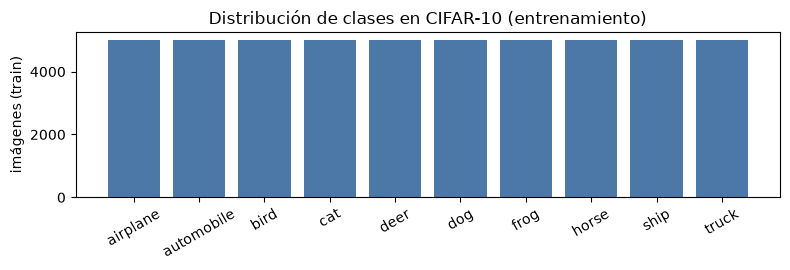

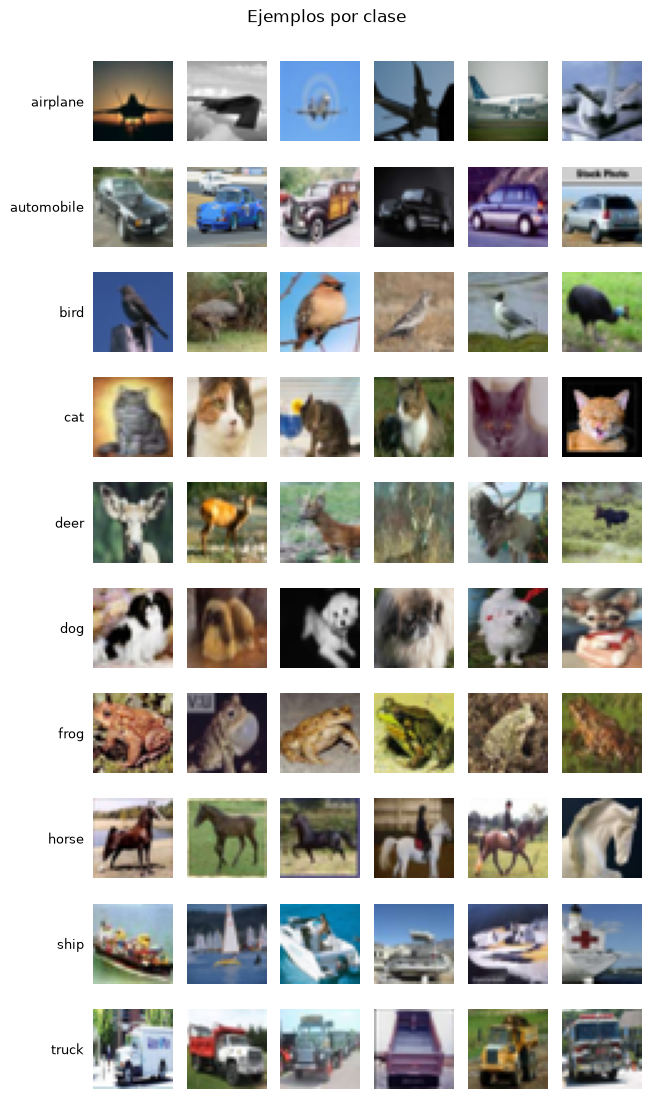

In [6]:
# Balance de clases + 6 ejemplos por clase.
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.bar(CLASES, conteo['train'], color='#4C78A8')
ax.set_ylabel('imágenes (train)'); ax.set_title('Distribución de clases en CIFAR-10 (entrenamiento)')
plt.xticks(rotation=30); plt.tight_layout()
fig.savefig(os.path.join(REPORTS, 'balance_clases.png'), dpi=150); plt.show()

rng = np.random.default_rng(SEED)
N_EJ = 6
fig, axes = plt.subplots(len(CLASES), N_EJ, figsize=(N_EJ * 1.1, len(CLASES) * 1.1))
for c, nombre in enumerate(CLASES):
    idx = rng.choice(np.where(y_full == c)[0], N_EJ, replace=False)
    for j, i in enumerate(idx):
        axes[c, j].imshow(X_full[i]); axes[c, j].axis('off')
    axes[c, 0].text(-4, 16, nombre, ha='right', va='center', fontsize=9)
plt.suptitle('Ejemplos por clase', y=1.0)
plt.tight_layout()
fig.savefig(os.path.join(REPORTS, 'ejemplos_por_clase.png'), dpi=150, bbox_inches='tight'); plt.show()

**Respuestas de la exploración.**

- **Observaciones y clases.** 60 000 imágenes: 50 000 de entrenamiento y 10 000 de test, en **10 clases**. El dataset
  está **perfectamente balanceado**: 5 000 imágenes por clase en train y 1 000 en test. Por eso accuracy y las
  métricas macro serán muy parecidas.
- **Resolución y canales.** 32×32 píxeles, **3 canales RGB** (uint8). La media por canal de CIFAR-10
  (≈0.491, 0.482, 0.447) y su desviación (≈0.247, 0.244, 0.262) son **muy cercanas** a las de ImageNet
  (0.485, 0.456, 0.406 / 0.229, 0.224, 0.225): ambos son fotografías naturales. Para la CNN desde cero normalizamos
  con las estadísticas de CIFAR; para VGG-16 usamos las de ImageNet, porque sus filtros aprendieron sobre entradas
  normalizadas así.
- **Pares difíciles.** Se espera más confusión entre **gato–perro** (mamíferos de forma, pelaje y pose similares),
  **automóvil–camión** (vehículos con ruedas, formas rectangulares), **venado–caballo** (cuadrúpedos sobre pasto) y
  **avión–barco/pájaro** (objetos sobre fondos uniformes de cielo o agua). A 32×32 se pierden los detalles finos
  (orejas, hocico, parrillas) que los distinguen.
- **Pipelines.** La **CNN desde cero** trabaja a resolución nativa: `ToImage → (augmentation) → ToDtype(float, [0,1])
  → Normalize(CIFAR)`. **VGG-16** necesita el mismo tipo de tensor, **redimensionado** y normalizado con ImageNet. Su
  `weights.transforms()` oficial hace `Resize(256) → CenterCrop(224)`; con imágenes de 32×32 el recorte central tira
  información, así que redimensionamos directamente a **112×112** (sin recorte). Pasar de 32×32 (1 024 píxeles) a
  224×224 (50 176) multiplica los píxeles por **49** y, como el costo de una convolución es proporcional al área del
  mapa de activación, el cómputo por imagen crece ~49×; a 112×112 (12 544 píxeles) crece ~12.25× respecto a 32×32 y es
  **4× más barato que 224×224**. Usamos 112×112 para ambos modelos VGG por restricción de cómputo (GPU integrada).
- **Data augmentation.** `RandomCrop(32, padding=4, reflect)` (traslaciones de hasta 4 píxeles) y
  `RandomHorizontalFlip` (los objetos de CIFAR-10 son simétricos izquierda-derecha: un gato volteado sigue siendo un
  gato). Aumentan la diversidad efectiva y reducen el overfitting sin cambiar la clase. **Solo se aplica al
  entrenamiento**: validación y test deben medir el desempeño sobre la distribución real de los datos, de forma
  determinista y comparable entre modelos; aumentar el test introduciría ruido y ya no sería una estimación honesta.

In [7]:
# --- Pipelines de preprocesamiento con torchvision (definición de referencia) ---
PESOS_VGG = models.VGG16_Weights.IMAGENET1K_V1
print('Transformación oficial de los pesos:', PESOS_VGG.transforms())

RES_VGG = 112   # resolución de entrada para ambos modelos VGG-16

aug = [T.RandomCrop(32, padding=4, padding_mode='reflect'), T.RandomHorizontalFlip()]
tf_cnn_train = T.Compose([T.ToImage(), *aug, T.ToDtype(torch.float32, scale=True), T.Normalize(CIFAR_MEAN, CIFAR_STD)])
tf_cnn_eval  = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True), T.Normalize(CIFAR_MEAN, CIFAR_STD)])
tf_vgg_train = T.Compose([T.ToImage(), *aug, T.Resize(RES_VGG, antialias=True),
                          T.ToDtype(torch.float32, scale=True), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
tf_vgg_eval  = T.Compose([T.ToImage(), T.Resize(RES_VGG, antialias=True),
                          T.ToDtype(torch.float32, scale=True), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

for nombre, px in [('32x32', 32), ('112x112', 112), ('224x224', 224)]:
    print(f'{nombre:>8}: {px*px:6d} píxeles  ->  x{px*px/1024:5.2f} respecto a 32x32')

Transformación oficial de los pesos: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
   32x32:   1024 píxeles  ->  x 1.00 respecto a 32x32
 112x112:  12544 píxeles  ->  x12.25 respecto a 32x32
 224x224:  50176 píxeles  ->  x49.00 respecto a 32x32


In [8]:
# --- Implementación equivalente en GPU (por batch) ---
# Aplicar las transformaciones imagen por imagen en la CPU es el cuello de botella al
# entrenar VGG-16 en una GPU integrada. Mantenemos el dataset uint8 en el dispositivo y
# hacemos crop/flip/resize/normalización por batch en la GPU, con las mismas operaciones.
_MEAN = {'cnn': torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1), 'vgg': torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)}
_STD  = {'cnn': torch.tensor(CIFAR_STD).view(1, 3, 1, 1),  'vgg': torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)}

def aumentar_batch(x, g):
    # x: uint8 (N,3,32,32). RandomCrop(32, padding=4, reflect) + RandomHorizontalFlip por imagen.
    n, dev = x.shape[0], x.device
    xp = F.pad(x.float(), (4, 4, 4, 4), mode='reflect')                  # (N,3,40,40)
    di = torch.randint(0, 9, (n,), generator=g).to(dev)
    dj = torch.randint(0, 9, (n,), generator=g).to(dev)
    ar = torch.arange(32, device=dev)
    filas, cols = di[:, None] + ar, dj[:, None] + ar                     # (N,32)
    xc = xp[torch.arange(n, device=dev)[:, None, None], :, filas[:, :, None], cols[:, None, :]]
    xc = xc.permute(0, 3, 1, 2)                                          # (N,3,32,32)
    voltear = (torch.rand(n, generator=g) < 0.5).to(dev)
    return torch.where(voltear[:, None, None, None], xc.flip(3), xc)

def preprocesar(x, modo):
    # modo='cnn' -> 32x32 + normalización CIFAR ; modo='vgg' -> 112x112 + normalización ImageNet
    x = x.float() / 255.0
    if modo == 'vgg':
        x = F.interpolate(x, size=(RES_VGG, RES_VGG), mode='bilinear', align_corners=False)
    return (x - _MEAN[modo].to(x.device)) / _STD[modo].to(x.device)

class CargadorGPU:
    # DataLoader minimalista: X uint8 (N,3,32,32) e y ya viven en el dispositivo.
    def __init__(self, X, y, batch_size, modo, entrenar=False, aumentar=False, seed=SEED):
        self.X, self.y, self.bs, self.modo = X, y, batch_size, modo
        self.entrenar, self.aumentar = entrenar, aumentar
        self.g = torch.Generator().manual_seed(seed)
    def __len__(self):
        return math.ceil(len(self.y) / self.bs)
    def __iter__(self):
        n = len(self.y)
        idx = (torch.randperm(n, generator=self.g) if self.entrenar else torch.arange(n)).to(self.X.device)
        for i in range(0, n, self.bs):
            b = idx[i:i + self.bs]
            x = self.X[b]
            if self.aumentar:
                x = aumentar_batch(x, self.g)
            yield preprocesar(x, self.modo), self.y[b]

# Verificación: el pipeline en GPU (sin augmentation) coincide con el de torchvision.
# (En VGG la pequeña diferencia viene de que torchvision redondea a uint8 después del Resize.)
img = X_full[0]
ref_cnn = tf_cnn_eval(img)
ref_vgg = tf_vgg_eval(img)
x0 = torch.from_numpy(img).permute(2, 0, 1)[None]
print('diferencia máx. CNN :', (preprocesar(x0, 'cnn')[0] - ref_cnn).abs().max().item())
print('diferencia máx. VGG :', (preprocesar(x0, 'vgg')[0] - ref_vgg).abs().max().item())

diferencia máx. CNN : 3.5762786865234375e-07
diferencia máx. VGG : 0.017509937286376953


train 45000 | val 5000 | test 10000
val por clase: [500 500 500 500 500 500 500 500 500 500]


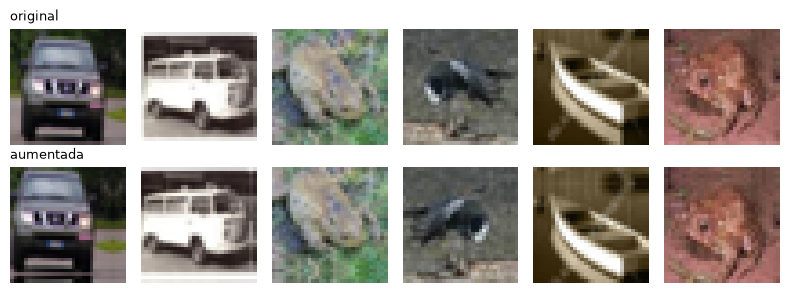

In [9]:
# División estratificada 45 000 / 5 000 del entrenamiento original; el test oficial se reserva.
idx_tr, idx_val = train_test_split(np.arange(len(y_full)), test_size=5000, stratify=y_full, random_state=SEED)
X_tr, y_tr   = X_full[idx_tr], y_full[idx_tr]
X_val, y_val = X_full[idx_val], y_full[idx_val]

if QUICK:   # prueba de humo
    X_tr, y_tr, X_val, y_val = X_tr[:2000], y_tr[:2000], X_val[:500], y_val[:500]
    X_test, y_test = X_test[:1000], y_test[:1000]

a_tensor = lambda X: torch.from_numpy(X).permute(0, 3, 1, 2).contiguous().to(DEVICE)
Xtr_t, ytr_t   = a_tensor(X_tr),  torch.from_numpy(y_tr).long().to(DEVICE)
Xval_t, yval_t = a_tensor(X_val), torch.from_numpy(y_val).long().to(DEVICE)
Xte_t, yte_t   = a_tensor(X_test), torch.from_numpy(y_test).long().to(DEVICE)

print('train', len(y_tr), '| val', len(y_val), '| test', len(y_test))
print('val por clase:', np.bincount(y_val))

# Ejemplos de data augmentation (solo para visualizar).
g = torch.Generator().manual_seed(SEED)
muestra = Xtr_t[:6]
aum = aumentar_batch(muestra, g).byte()
fig, axes = plt.subplots(2, 6, figsize=(8, 3))
for j in range(6):
    axes[0, j].imshow(muestra[j].permute(1, 2, 0).cpu()); axes[0, j].axis('off')
    axes[1, j].imshow(aum[j].permute(1, 2, 0).cpu()); axes[1, j].axis('off')
axes[0, 0].set_title('original', fontsize=9, loc='left'); axes[1, 0].set_title('aumentada', fontsize=9, loc='left')
plt.tight_layout(); plt.show()

## 3. Investigación: transfer learning en PyTorch

- **`torchvision.models.vgg16(weights=...)` y `VGG16_Weights`** [1][2]. Construye la arquitectura VGG-16 (13 convoluciones
  3×3 + 3 capas densas, ~138 M de parámetros). `weights=VGG16_Weights.IMAGENET1K_V1` descarga los pesos entrenados en
  ImageNet-1k (71.6 % top-1); `weights=None` inicializa aleatoriamente; `progress` muestra la descarga. Cada enum de
  pesos trae metadatos (`meta['categories']`, métricas) y **`weights.transforms()`**, que devuelve el preprocesamiento
  exacto usado al entrenarlos: `Resize(256)` bilineal → `CenterCrop(224)` → escala a [0,1] → `Normalize` con media
  (0.485, 0.456, 0.406) y std (0.229, 0.224, 0.225).
- **Estructura del modelo** [1]. `model.features` es un `nn.Sequential` con los **5 bloques convolucionales**
  (conv3×3+ReLU, cerrando cada bloque con `MaxPool2d(2)`; índices 0–4, 5–9, 10–16, 17–23 y 24–30). `model.avgpool` es un
  `nn.AdaptiveAvgPool2d((7, 7))`: promedia el mapa de activación hasta una salida **fija de 7×7** sin importar la
  resolución de entrada, lo que permite usar imágenes de 112×112 con el clasificador original (entrada 512·7·7 = 25 088).
  `model.classifier` es `Linear(25088,4096)–ReLU–Dropout–Linear(4096,4096)–ReLU–Dropout–Linear(4096,1000)`; la última
  capa (`classifier[6]`) se reemplaza por `Linear(4096, 10)`. *Nota:* en MPS, `AdaptiveAvgPool2d` no admite tamaños no
  divisibles (3×3 → 7×7 a 112 px), así que lo sustituimos por un módulo equivalente basado en matrices de pooling.
- **`requires_grad`** [3]. Atributo de cada `Parameter`; si es `False`, autograd no calcula ni guarda su gradiente y el
  optimizador no lo actualiza. Se **congela** un bloque con `for p in model.features[i:j].parameters():
  p.requires_grad = False` (o `module.requires_grad_(False)`) y se descongela con `True`. Si todo lo que está por debajo
  de una capa está congelado, autograd ni siquiera hace backward por esa parte (ahorro de tiempo y memoria).
- **`model.train()` / `model.eval()` / `torch.no_grad()`** [3]. `train()` y `eval()` cambian el **modo** de capas como
  `Dropout` (activo/inactivo) y `BatchNorm` (estadísticas del batch vs. promedios móviles); **no** congelan pesos.
  `torch.no_grad()` es un contexto que desactiva el registro del grafo de autograd: se usa en validación/inferencia para
  ahorrar memoria y tiempo. Congelar (`requires_grad`) y `eval()` son cosas distintas.
- **Grupos de parámetros (`param_groups`)** [4]. Los optimizadores aceptan una lista de diccionarios,
  p. ej. `SGD([{'params': backbone, 'lr': 1e-3}, {'params': head, 'lr': 1e-2}], momentum=0.9)`; cada grupo puede tener
  su propio `lr`, `weight_decay`, etc., y los schedulers escalan cada grupo. Así se usa un **learning rate menor para el
  backbone preentrenado** (no destruir sus features) y uno mayor para el clasificador nuevo.
- **Conteo de parámetros y operaciones** [5]. `torchinfo.summary(model, input_size=(1,3,112,112))` muestra por capa la
  forma de salida, los parámetros (totales / entrenables) y los *mult-adds*. `fvcore.nn.FlopCountAnalysis(model, x)` traza
  el modelo y cuenta operaciones por módulo (`.total()`, `.by_module()`); **fvcore reporta MACs** (una multiplicación-suma
  fusionada = 1 "flop"). `thop` y `ptflops` son alternativas similares.
- **Memoria y tiempo en GPU** [6]. Las operaciones de CUDA son **asíncronas**: `time.time()` sin
  `torch.cuda.synchronize()` mide solo el lanzamiento de kernels, así que se sincroniza antes de tomar cada tiempo.
  `torch.cuda.max_memory_allocated()` devuelve el pico de memoria ocupada por tensores desde el último
  `torch.cuda.reset_peak_memory_stats()`. En Apple Silicon los equivalentes son `torch.mps.synchronize()` y
  `torch.mps.current_allocated_memory()` (no hay contador de pico, por lo que lo muestreamos en cada paso).
- **MACs vs. FLOPs.** Un **MAC** (*multiply–accumulate*) es una multiplicación seguida de una suma, `a ← a + b·c`. Un
  **FLOP** es una sola operación de punto flotante, así que **1 MAC ≈ 2 FLOPs**. Una convolución con salida
  H·W·C_out y kernel k×k×C_in cuesta H·W·C_out·k²·C_in MACs. El backward cuesta ≈ 2× el forward (gradiente respecto a
  la entrada y respecto a los pesos), por lo que entrenar una capa cuesta ≈ 3× su forward.
- **Parámetros totales vs. entrenables.** Los **totales** son todos los pesos del modelo (determinan memoria de
  almacenamiento y costo de inferencia); los **entrenables** son los que tienen `requires_grad=True` y reciben
  gradiente y estado del optimizador (determinan memoria y cómputo de entrenamiento y cuántos datos hacen falta para no
  sobreajustar). En feature extraction VGG-16 tiene 134 M totales pero solo ~119 M entrenables en el clasificador; en un
  *linear probe* solo 41 k.

*Referencias:* [1] PyTorch, *torchvision.models — VGG16*. [2] Simonyan & Zisserman (2015), *Very Deep Convolutional
Networks for Large-Scale Image Recognition*, ICLR. [3] PyTorch, *Autograd mechanics* / *nn.Module.train, eval* y
*torch.no_grad*. [4] PyTorch, *torch.optim — per-parameter options*. [5] torchinfo (T. Yep) y fvcore (Meta AI), docs.
[6] PyTorch, *CUDA semantics — memory management* y *torch.mps*. [7] Yosinski et al. (2014), *How transferable are
features in deep neural networks?*, NeurIPS.

## 4. Construcción y entrenamiento de los modelos

### 4.0 Definición de los tres modelos

In [10]:
# --- (a) CNN desde cero (resolución nativa 32x32) ---
class CNNDesdeCero(nn.Module):
    # canales: uno por bloque; cada bloque = convs_por_bloque x (Conv3x3 [+BN] + ReLU) + MaxPool(2) [+ Dropout]
    def __init__(self, canales=(32, 64, 128), convs_por_bloque=1, bn=True, p_conv=0.1, p_fc=0.3, fc=256):
        super().__init__()
        capas, c_in = [], 3
        for c in canales:
            for _ in range(convs_por_bloque):
                capas.append(nn.Conv2d(c_in, c, 3, padding=1, bias=not bn))
                if bn:
                    capas.append(nn.BatchNorm2d(c))
                capas.append(nn.ReLU(inplace=True))
                c_in = c
            capas.append(nn.MaxPool2d(2))
            if p_conv > 0:
                capas.append(nn.Dropout(p_conv))
        self.features = nn.Sequential(*capas)
        lado = 32 // 2 ** len(canales)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(c_in * lado * lado, fc), nn.ReLU(inplace=True),
            nn.Dropout(p_fc), nn.Linear(fc, 10))
    def forward(self, x):
        return self.classifier(self.features(x))


# --- AdaptiveAvgPool2d equivalente que funciona en MPS con tamaños no divisibles ---
def _matriz_pool(n_in, n_out):
    # Fila i = promedio de la ventana [floor(i*n_in/n_out), ceil((i+1)*n_in/n_out)), igual que PyTorch.
    M = torch.zeros(n_out, n_in)
    for i in range(n_out):
        ini, fin = (i * n_in) // n_out, math.ceil((i + 1) * n_in / n_out)
        M[i, ini:fin] = 1.0 / (fin - ini)
    return M

class AdaptiveAvgPool2dMPS(nn.Module):
    def __init__(self, output_size=(7, 7)):
        super().__init__(); self.output_size = output_size
    def forward(self, x):
        (h, w), (oh, ow) = x.shape[-2:], self.output_size
        return torch.einsum('oh,nchw,pw->ncop', _matriz_pool(h, oh).to(x), x, _matriz_pool(w, ow).to(x))

xp = torch.randn(2, 512, 3, 3)
print('pool MPS vs nn.AdaptiveAvgPool2d, diferencia máx.:',
      (AdaptiveAvgPool2dMPS()(xp) - nn.AdaptiveAvgPool2d(7)(xp)).abs().max().item())


# --- (b) y (c) VGG-16 preentrenada: feature extractor o fine-tuning ---
# Índices de cada bloque convolucional dentro de model.features.
BLOQUES_VGG = {1: (0, 5), 2: (5, 10), 3: (10, 17), 4: (17, 24), 5: (24, 31)}

def construir_vgg(bloques_descongelados=0, solo_ultima_capa=False, p_drop=0.5):
    m = models.vgg16(weights=PESOS_VGG)
    m.avgpool = AdaptiveAvgPool2dMPS((7, 7))
    m.classifier[2].p = p_drop; m.classifier[5].p = p_drop
    m.classifier[6] = nn.Linear(4096, 10)                 # nueva capa de 10 salidas
    m.features.requires_grad_(False)                      # congelar todo el backbone
    for b in range(6 - bloques_descongelados, 6):         # descongelar los bloques superiores
        ini, fin = BLOQUES_VGG[b]
        m.features[ini:fin].requires_grad_(True)
    if solo_ultima_capa:                                  # linear probe: fc6 y fc7 también congeladas
        m.classifier[0].requires_grad_(False); m.classifier[3].requires_grad_(False)
    return m

def construir_modelo(cfg):
    if cfg['familia'] == 'cnn':
        return CNNDesdeCero(cfg['canales'], cfg['convs'], cfg['bn'], cfg['p_conv'], cfg['p_fc'])
    return construir_vgg(cfg.get('bloques', 0), cfg.get('solo_ultima_capa', False), cfg.get('p_drop', 0.5))

def indice_primera_entrenable(modelo):
    # Primer índice de model.features con parámetros entrenables (None si todo el backbone está congelado).
    for i, capa in enumerate(modelo.features):
        if any(p.requires_grad for p in capa.parameters()):
            return i
    return None

for nombre, m in [('CNN (3 bloques)', CNNDesdeCero()),
                  ('VGG-16 feature extractor', construir_vgg(0)),
                  ('VGG-16 fine-tuning b4-5', construir_vgg(2))]:
    tot, ent = contar_parametros(m)
    print(f'{nombre:<26} parámetros totales = {tot:>12,} | entrenables = {ent:>12,}')

pool MPS vs nn.AdaptiveAvgPool2d, diferencia máx.: 2.384185791015625e-07


CNN (3 bloques)            parámetros totales =      620,586 | entrenables =      620,586
VGG-16 feature extractor   parámetros totales =  134,301,514 | entrenables =  119,586,826
VGG-16 fine-tuning b4-5    parámetros totales =  134,301,514 | entrenables =  132,566,026


### 4.1 Rutina de entrenamiento y evaluación

Cada iteración registra la configuración, la pérdida de entrenamiento y validación por epoch, accuracy/precision/recall/F1
macro en validación, parámetros totales y entrenables, tiempo por epoch y total, y memoria pico en el dispositivo. Se
conserva el **checkpoint del mejor epoch** según F1 macro de validación (*early stopping* implícito).

In [11]:
def metricas(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(y_true, y_pred), 'precision': p, 'recall': r, 'f1': f1}

@torch.no_grad()
def evaluar(modelo, X, y, modo, bs=500):
    modelo.eval()
    perdida, preds = 0.0, []
    for xb, yb in CargadorGPU(X, y, bs, modo):
        out = modelo(xb)
        perdida += F.cross_entropy(out, yb, reduction='sum').item()
        preds.append(out.argmax(1).cpu())
    preds = torch.cat(preds).numpy()
    return perdida / len(y), preds

def crear_optimizador(modelo, cfg):
    # Grupos de parámetros: backbone (features) con lr_backbone y clasificador con lr.
    back = [p for p in modelo.features.parameters() if p.requires_grad]
    head = [p for p in modelo.classifier.parameters() if p.requires_grad]
    grupos = [{'params': head, 'lr': cfg['lr']}]
    if back:
        grupos.append({'params': back, 'lr': cfg.get('lr_backbone', cfg['lr'])})
    if cfg['opt'] == 'sgd':
        return torch.optim.SGD(grupos, momentum=0.9, nesterov=True, weight_decay=cfg.get('wd', 0))
    if cfg['opt'] == 'adamw':
        return torch.optim.AdamW(grupos, weight_decay=cfg.get('wd', 0))
    return torch.optim.Adam(grupos, weight_decay=cfg.get('wd', 0))

def crear_scheduler(opt, cfg, pasos_totales):
    if cfg.get('sched') == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=pasos_totales)
    if cfg.get('sched') == 'onecycle':
        return torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g['lr'] for g in opt.param_groups],
                                                   total_steps=pasos_totales)
    return None

def entrenar(cfg, X, y, Xv, yv, epochs=None, verbose=True):
    fijar_semillas(SEED)
    epochs = 1 if QUICK else (epochs or cfg['epochs'])
    modo = 'cnn' if cfg['familia'] == 'cnn' else 'vgg'
    reiniciar_memoria()
    modelo = construir_modelo(cfg).to(DEVICE)
    total, entrenables = contar_parametros(modelo)
    opt = crear_optimizador(modelo, cfg)
    loader = CargadorGPU(X, y, cfg['bs'], modo, entrenar=True, aumentar=cfg['aug'])
    sched = crear_scheduler(opt, cfg, epochs * len(loader))
    hist = {k: [] for k in ['train_loss', 'val_loss', 'accuracy', 'precision', 'recall', 'f1', 't_epoch']}
    mejor_f1, mejor_estado, mejor_ep, pico = -1.0, None, 0, memoria_actual()

    for ep in range(1, epochs + 1):
        modelo.train()
        sincronizar(); t0 = time.perf_counter()
        suma = torch.zeros((), device=DEVICE)
        for xb, yb in loader:
            loss = F.cross_entropy(modelo(xb), yb)
            pico = max(pico, memoria_actual())            # activaciones del forward en memoria
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            if sched: sched.step()
            suma += loss.detach() * len(yb)
        sincronizar(); t_ep = time.perf_counter() - t0   # tiempo de entrenamiento del epoch

        val_loss, pred = evaluar(modelo, Xv, yv, modo)
        m = metricas(yv.cpu().numpy(), pred)
        hist['train_loss'].append(suma.item() / len(y)); hist['val_loss'].append(val_loss)
        hist['t_epoch'].append(t_ep)
        for k in m: hist[k].append(m[k])
        if m['f1'] > mejor_f1:
            mejor_f1, mejor_ep = m['f1'], ep
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        if os.environ.get('LAB6_LOG'):   # log de progreso opcional (útil al ejecutar con nbconvert)
            with open(os.environ['LAB6_LOG'], 'a') as f:
                f.write(f"{time.strftime('%H:%M:%S')} {cfg['nombre']} ep {ep}/{epochs} val_f1={m['f1']:.4f} t={t_ep:.0f}s\n")
        if verbose:
            print(f"  [{cfg['nombre']}] ep {ep:2d}/{epochs} | train {hist['train_loss'][-1]:.4f} "
                  f"| val {val_loss:.4f} | acc {m['accuracy']:.4f} | f1 {m['f1']:.4f} | {t_ep:6.1f}s")

    modelo.load_state_dict(mejor_estado)                  # nos quedamos con el mejor epoch
    res = {
        'cfg': cfg, 'hist': hist, 'epochs': epochs, 'mejor_epoch': mejor_ep,
        'val': {k: hist[k][mejor_ep - 1] for k in ['accuracy', 'precision', 'recall', 'f1']},
        'params_total': total, 'params_entrenables': entrenables,
        't_epoch_prom': float(np.mean(hist['t_epoch'])), 't_total': float(np.sum(hist['t_epoch'])),
        't_hasta_mejor': float(np.sum(hist['t_epoch'][:mejor_ep])),
        'mem_pico_MB': memoria_pico(pico) / 2**20, 'n_train': len(y),
    }
    return modelo, res

### 4.2 Iteraciones

| Modelo | Iteración | Cambio principal |
|---|---|---|
| CNN desde cero | CNN-1 | 3 bloques (32-64-128), **sin** BN / dropout / augmentation, Adam 1e-3 (línea base) |
| | CNN-2 | + BatchNorm + dropout + augmentation, AdamW + cosine, 25 epochs |
| | CNN-3 | red más ancha y profunda (64-128-256, 2 convs por bloque), SGD Nesterov + OneCycle, 30 epochs |
| VGG-16 feature extractor | FE-1 | clasificador completo (fc6–fc8), SGD lr 1e-2, sin augmentation |
| | FE-2 | igual + augmentation |
| | FE-3 | *linear probe*: solo fc8 entrenable (fc6/fc7 también congeladas) |
| VGG-16 fine-tuning | FT-1 | bloque 5 descongelado, lr backbone 1e-3 / clasificador 1e-2 |
| | FT-2 | bloques 4–5, lr backbone 1e-3 |
| | FT-3 | bloques 4–5, lr backbone **1e-4** |
| | FT-4 | bloques 3–5, lr backbone 1e-3 |

In [12]:
CONFIGS = {
    'cnn': [
        dict(nombre='CNN-1', familia='cnn', canales=(32, 64, 128), convs=1, bn=False, p_conv=0.0, p_fc=0.0,
             aug=False, opt='adam', lr=1e-3, wd=0.0, sched=None, epochs=15, bs=128),
        dict(nombre='CNN-2', familia='cnn', canales=(32, 64, 128), convs=1, bn=True, p_conv=0.1, p_fc=0.3,
             aug=True, opt='adamw', lr=1e-3, wd=5e-4, sched='cosine', epochs=25, bs=128),
        dict(nombre='CNN-3', familia='cnn', canales=(64, 128, 256), convs=2, bn=True, p_conv=0.2, p_fc=0.4,
             aug=True, opt='sgd', lr=0.1, wd=5e-4, sched='onecycle', epochs=30, bs=128),
    ],
    'fe': [
        dict(nombre='FE-1', familia='vgg', bloques=0, aug=False, opt='sgd', lr=1e-2, wd=5e-4,
             sched='cosine', epochs=5, bs=128),
        dict(nombre='FE-2', familia='vgg', bloques=0, aug=True, opt='sgd', lr=1e-2, wd=5e-4,
             sched='cosine', epochs=5, bs=128),
        dict(nombre='FE-3', familia='vgg', bloques=0, solo_ultima_capa=True, aug=True, opt='sgd', lr=1e-2,
             wd=5e-4, sched='cosine', epochs=5, bs=128),
    ],
    'ft': [
        dict(nombre='FT-1', familia='vgg', bloques=1, aug=True, opt='sgd', lr=1e-2, lr_backbone=1e-3,
             wd=5e-4, sched='cosine', epochs=5, bs=128),
        dict(nombre='FT-2', familia='vgg', bloques=2, aug=True, opt='sgd', lr=1e-2, lr_backbone=1e-3,
             wd=5e-4, sched='cosine', epochs=5, bs=128),
        dict(nombre='FT-3', familia='vgg', bloques=2, aug=True, opt='sgd', lr=1e-2, lr_backbone=1e-4,
             wd=5e-4, sched='cosine', epochs=5, bs=128),
        dict(nombre='FT-4', familia='vgg', bloques=3, aug=True, opt='sgd', lr=1e-2, lr_backbone=1e-3,
             wd=5e-4, sched='cosine', epochs=5, bs=128),
    ],
}
NOMBRE_FAMILIA = {'cnn': 'CNN desde cero', 'fe': 'VGG-16 feature extractor', 'ft': 'VGG-16 fine-tuning'}

RESULTADOS = {}   # nombre de iteración -> resultados
MEJORES = {}      # familia -> (nombre, modelo) de la mejor iteración según F1 de validación

def correr_familia(fam):
    for cfg in CONFIGS[fam]:
        print(f"\n=== {cfg['nombre']} ===")
        modelo, res = entrenar(cfg, Xtr_t, ytr_t, Xval_t, yval_t)
        res['familia'] = fam
        RESULTADOS[cfg['nombre']] = res
        tot, ent = res['params_total'], res['params_entrenables']
        print(f"  mejor epoch {res['mejor_epoch']} | val F1 {res['val']['f1']:.4f} | params {tot:,} "
              f"(entrenables {ent:,}) | {res['t_epoch_prom']:.1f}s/epoch | total {res['t_total']/60:.1f} min "
              f"| mem pico {res['mem_pico_MB']:.0f} MB")
        if fam not in MEJORES or res['val']['f1'] > RESULTADOS[MEJORES[fam][0]]['val']['f1']:
            MEJORES[fam] = (cfg['nombre'], modelo.cpu())
        else:
            del modelo
        reiniciar_memoria()

#### CNN desde cero

In [13]:
correr_familia('cnn')


=== CNN-1 ===


  [CNN-1] ep  1/15 | train 1.4336 | val 1.1223 | acc 0.5930 | f1 0.5878 |    2.4s


  [CNN-1] ep  2/15 | train 0.9979 | val 0.9009 | acc 0.6812 | f1 0.6844 |    2.2s


  [CNN-1] ep  3/15 | train 0.8103 | val 0.7885 | acc 0.7196 | f1 0.7206 |    2.2s


  [CNN-1] ep  4/15 | train 0.6841 | val 0.7346 | acc 0.7396 | f1 0.7394 |    2.1s


...

  [CNN-3] ep 26/30 | train 0.2612 | val 0.2670 | acc 0.9118 | f1 0.9116 |   11.6s


  [CNN-3] ep 27/30 | train 0.2269 | val 0.2633 | acc 0.9130 | f1 0.9129 |   11.6s


  [CNN-3] ep 28/30 | train 0.1991 | val 0.2398 | acc 0.9202 | f1 0.9198 |   11.7s


  [CNN-3] ep 29/30 | train 0.1801 | val 0.2326 | acc 0.9228 | f1 0.9226 |   11.6s


  [CNN-3] ep 30/30 | train 0.1679 | val 0.2324 | acc 0.9254 | f1 0.9252 |   11.7s
  mejor epoch 30 | val F1 0.9252 | params 2,197,706 (entrenables 2,197,706) | 11.6s/epoch | total 5.8 min | mem pico 462 MB


#### VGG-16 como feature extractor

In [14]:
correr_familia('fe')


=== FE-1 ===


  [FE-1] ep  1/5 | train 0.6160 | val 0.4425 | acc 0.8468 | f1 0.8466 |   82.9s


  [FE-1] ep  2/5 | train 0.3902 | val 0.3830 | acc 0.8700 | f1 0.8701 |   83.5s


  [FE-1] ep  3/5 | train 0.2806 | val 0.3623 | acc 0.8772 | f1 0.8773 |   84.1s


  [FE-1] ep  4/5 | train 0.2130 | val 0.3590 | acc 0.8776 | f1 0.8776 |   83.9s


...

  [FE-3] ep  1/5 | train 1.0310 | val 0.7149 | acc 0.7808 | f1 0.7795 |   72.9s


  [FE-3] ep  2/5 | train 0.9846 | val 0.6209 | acc 0.8026 | f1 0.8016 |   73.3s


  [FE-3] ep  3/5 | train 0.8722 | val 0.5620 | acc 0.8132 | f1 0.8115 |   73.5s


  [FE-3] ep  4/5 | train 0.7652 | val 0.5117 | acc 0.8244 | f1 0.8232 |   73.5s


  [FE-3] ep  5/5 | train 0.7020 | val 0.5014 | acc 0.8282 | f1 0.8272 |   73.4s
  mejor epoch 5 | val F1 0.8272 | params 134,301,514 (entrenables 40,970) | 73.3s/epoch | total 6.1 min | mem pico 713 MB


#### VGG-16 con fine-tuning

In [15]:
correr_familia('ft')


=== FT-1 ===


  [FT-1] ep  1/5 | train 0.5801 | val 0.3802 | acc 0.8740 | f1 0.8735 |  103.8s


  [FT-1] ep  2/5 | train 0.3808 | val 0.3207 | acc 0.8910 | f1 0.8906 |  104.4s


  [FT-1] ep  3/5 | train 0.3169 | val 0.3053 | acc 0.8956 | f1 0.8951 |  103.4s


  [FT-1] ep  4/5 | train 0.2752 | val 0.2883 | acc 0.9010 | f1 0.9007 |  102.9s


...

  [FT-4] ep  1/5 | train 0.4610 | val 0.2765 | acc 0.9104 | f1 0.9099 |  216.5s


  [FT-4] ep  2/5 | train 0.2659 | val 0.2248 | acc 0.9234 | f1 0.9233 |  203.1s


  [FT-4] ep  3/5 | train 0.2070 | val 0.2038 | acc 0.9324 | f1 0.9322 |  206.3s


  [FT-4] ep  4/5 | train 0.1701 | val 0.1997 | acc 0.9328 | f1 0.9327 |  208.1s


  [FT-4] ep  5/5 | train 0.1536 | val 0.1950 | acc 0.9344 | f1 0.9343 |  218.5s
  mejor epoch 5 | val F1 0.9343 | params 134,301,514 (entrenables 134,041,354) | 210.5s/epoch | total 17.5 min | mem pico 2323 MB


In [16]:
# Tabla de todas las iteraciones (métricas sobre validación en el mejor epoch).
def tabla_iteraciones():
    filas = []
    for nombre, r in RESULTADOS.items():
        c = r['cfg']
        if c['familia'] == 'cnn':
            congeladas = '—'
            detalle = f"{'-'.join(map(str, c['canales']))} x{c['convs']}, BN={c['bn']}, drop={c['p_conv']}/{c['p_fc']}"
        else:
            b = c.get('bloques', 0)
            congeladas = ('b1–b5 + fc6–fc7' if c.get('solo_ultima_capa') else
                          'b1–b5' if b == 0 else f'b1–b{5-b}')
            detalle = f"lr_bb={c.get('lr_backbone', '—')}"
        filas.append({
            'iter': nombre, 'config': detalle, 'congeladas': congeladas, 'aug': c['aug'],
            'opt': f"{c['opt']} lr={c['lr']}", 'epochs': r['epochs'], 'mejor ep': r['mejor_epoch'],
            'acc': r['val']['accuracy'], 'prec': r['val']['precision'], 'rec': r['val']['recall'],
            'F1': r['val']['f1'], 'params (M)': r['params_total'] / 1e6,
            'entren. (M)': r['params_entrenables'] / 1e6, 's/epoch': r['t_epoch_prom'],
            'total (min)': r['t_total'] / 60, 'mem (MB)': r['mem_pico_MB']})
    return pd.DataFrame(filas).set_index('iter')

tab_it = tabla_iteraciones()
tab_it.to_csv(os.path.join(REPORTS, 'tabla_iteraciones.csv'))
display(tab_it.round(4))
print('Mejores configuraciones:', {f: n for f, (n, _) in MEJORES.items()})

,config,congeladas,aug,opt,epochs,mejor ep,acc,prec,rec,F1,params (M),entren. (M),s/epoch,total (min),mem (MB)
iter,,,,,,,,,,,,,,,
CNN-1,"32-64-128 x1, BN=False, drop=0.0/0.0",—,False,adam lr=0.001,15,11,0.7634,0.7629,0.7634,0.7622,0.6204,0.6204,2.1697,0.5424,224.0437
CNN-2,"32-64-128 x1, BN=True, drop=0.1/0.3",—,True,adamw lr=0.001,25,20,0.8216,0.8205,0.8216,0.8204,0.6206,0.6206,2.4916,1.0382,262.6772
CNN-3,"64-128-256 x2, BN=True, drop=0.2/0.4",—,True,sgd lr=0.1,30,30,0.9254,0.9254,0.9254,0.9252,2.1977,2.1977,11.6497,5.8248,462.4924
FE-1,lr_bb=—,b1–b5,False,sgd lr=0.01,5,5,0.8792,0.8796,0.8792,0.8792,134.3015,119.5868,83.7775,6.9815,1645.7712
FE-2,lr_bb=—,b1–b5,True,sgd lr=0.01,5,4,0.8720,0.8724,0.8720,0.8715,134.3015,119.5868,85.0718,7.0893,1647.3962
FE-3,lr_bb=—,b1–b5 + fc6–fc7,True,sgd lr=0.01,5,5,0.8282,0.8287,0.8282,0.8272,134.3015,0.0410,73.3429,6.1119,712.5837
FT-1,lr_bb=0.001,b1–b4,True,sgd lr=0.01,5,5,0.9016,0.9016,0.9016,0.9013,134.3015,126.6662,103.5156,8.6263,1750.4084
FT-2,lr_bb=0.001,b1–b3,True,sgd lr=0.01,5,5,0.9256,0.9257,0.9256,0.9255,134.3015,132.5660,153.5675,12.7973,1968.4202
FT-3,lr_bb=0.0001,b1–b3,True,sgd lr=0.01,5,5,0.9024,0.9025,0.9024,0.9022,134.3015,132.5660,155.8308,12.9859,1968.9202


Mejores configuraciones: {'cnn': 'CNN-3', 'fe': 'FE-1', 'ft': 'FT-4'}


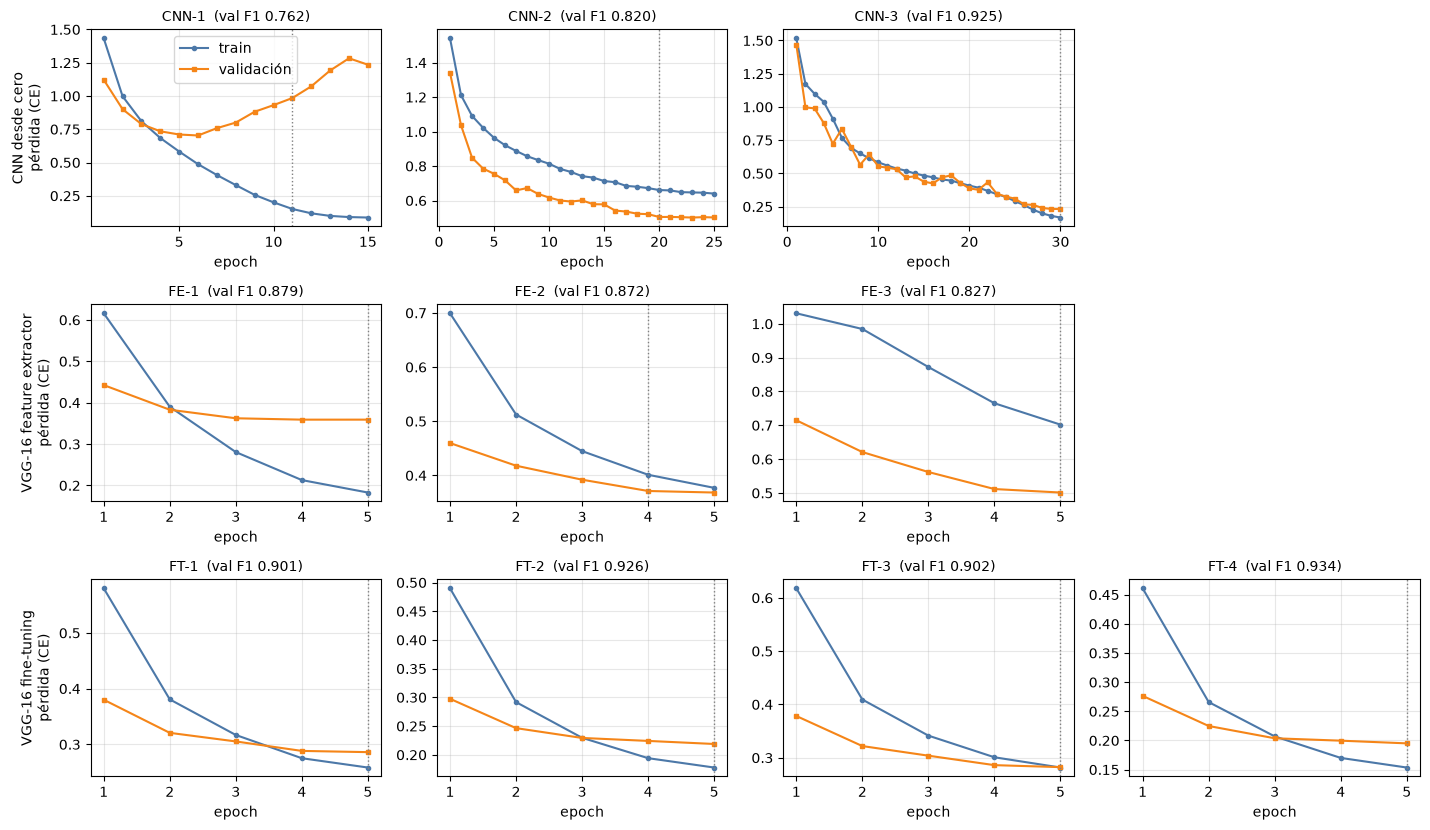

In [17]:
# Curvas de pérdida de entrenamiento y validación (todas las iteraciones).
max_cols = max(len(v) for v in CONFIGS.values())
fig, axes = plt.subplots(3, max_cols, figsize=(3.6 * max_cols, 8.4), squeeze=False)
for i, fam in enumerate(['cnn', 'fe', 'ft']):
    for j in range(max_cols):
        ax = axes[i, j]
        if j >= len(CONFIGS[fam]):
            ax.axis('off'); continue
        nombre = CONFIGS[fam][j]['nombre']; h = RESULTADOS[nombre]['hist']
        ep = np.arange(1, len(h['train_loss']) + 1)
        ax.plot(ep, h['train_loss'], 'o-', ms=3, label='train', color='#4C78A8')
        ax.plot(ep, h['val_loss'], 's-', ms=3, label='validación', color='#F58518')
        ax.axvline(RESULTADOS[nombre]['mejor_epoch'], color='gray', ls=':', lw=1)
        ax.set_title(f"{nombre}  (val F1 {RESULTADOS[nombre]['val']['f1']:.3f})", fontsize=10)
        ax.set_xlabel('epoch'); ax.grid(alpha=0.3)
        if j == 0: ax.set_ylabel(f'{NOMBRE_FAMILIA[fam]}\npérdida (CE)')
axes[0, 0].legend()
plt.tight_layout()
fig.savefig(os.path.join(REPORTS, 'curvas_perdida.png'), dpi=150); plt.show()

### 4.3 Evaluación final sobre test (una única vez)

Con la mejor configuración de cada modelo (según F1 macro de validación) evaluamos **una sola vez** sobre el test oficial.

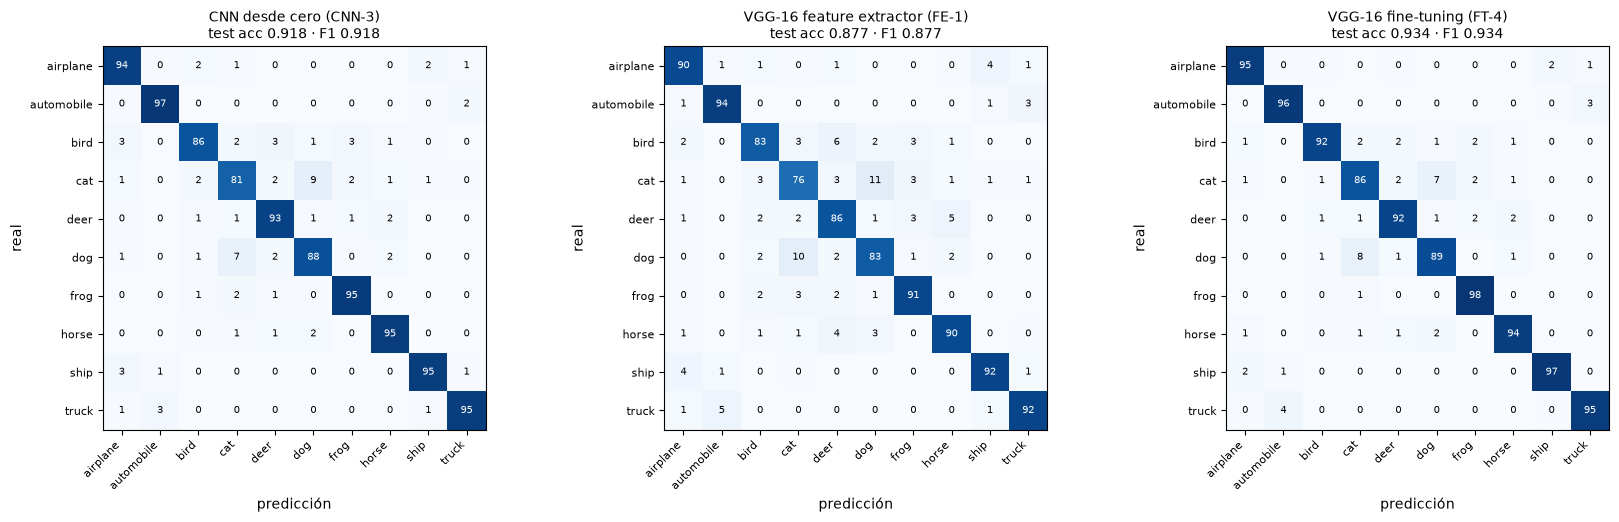

,accuracy,precision,recall,f1
CNN desde cero,0.9183,0.9181,0.9183,0.9180
VGG-16 feature extractor,0.8771,0.8769,0.8771,0.8768
VGG-16 fine-tuning,0.9340,0.9339,0.9340,0.9339


CNN desde cero             cat-dog: 15.4% | automobile-truck: 5.0% | airplane-ship: 5.0% | bird-deer: 4.2%
VGG-16 feature extractor   cat-dog: 20.9% | deer-horse: 8.6% | airplane-ship: 8.5% | bird-deer: 8.1%
VGG-16 fine-tuning         cat-dog: 14.5% | automobile-truck: 6.7% | airplane-ship: 4.1% | deer-horse: 3.6%


In [18]:
TEST = {}
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, fam in zip(axes, ['cnn', 'fe', 'ft']):
    nombre, modelo = MEJORES[fam]
    modelo.to(DEVICE)
    _, pred = evaluar(modelo, Xte_t, yte_t, 'cnn' if fam == 'cnn' else 'vgg')
    modelo.cpu(); reiniciar_memoria()
    TEST[fam] = metricas(y_test, pred)
    cm = confusion_matrix(y_test, pred, normalize='true')
    TEST[fam]['cm'] = cm
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for a in range(10):
        for b in range(10):
            ax.text(b, a, f'{cm[a, b]*100:.0f}', ha='center', va='center', fontsize=7,
                    color='white' if cm[a, b] > 0.5 else 'black')
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASES, fontsize=8)
    ax.set_xlabel('predicción'); ax.set_ylabel('real')
    ax.set_title(f"{NOMBRE_FAMILIA[fam]} ({nombre})\ntest acc {TEST[fam]['accuracy']:.3f} · F1 {TEST[fam]['f1']:.3f}",
                 fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(REPORTS, 'matrices_confusion.png'), dpi=150); plt.show()

display(pd.DataFrame({NOMBRE_FAMILIA[f]: {k: TEST[f][k] for k in ['accuracy', 'precision', 'recall', 'f1']}
                      for f in TEST}).T.round(4))

# Pares de clases más confundidos por modelo (suma de ambos sentidos, % del test de cada clase).
for fam in TEST:
    cm = TEST[fam]['cm']; pares = []
    for a in range(10):
        for b in range(a + 1, 10):
            pares.append((cm[a, b] + cm[b, a], CLASES[a], CLASES[b]))
    top = sorted(pares, reverse=True)[:4]
    print(f"{NOMBRE_FAMILIA[fam]:<26}", ' | '.join(f'{x}-{z}: {v*100:.1f}%' for v, x, z in top))